In [4]:
#Data manipulation:
import pandas as pd
import numpy as np
#Visualization:
import matplotlib.pyplot as plt
import seaborn as sns
#Scikit-learn:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline as sk_Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc, average_precision_score)
#Imbalanced learn:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as imb_Pipeline
#XGBoost:
from xgboost import XGBClassifier
#Utils:
import importlib
import copy

In [5]:
import set_paths
import src.utils as utils
import src.models_tools as mt
import src.visualization_tools as vt

In [6]:
data = pd.read_csv(r'..\data\clean.csv')
features = data.iloc[:, 1:]
target = data.iloc[:, 0]
n_splits = 5
seed = 1105
fold_maker = StratifiedKFold(n_splits= n_splits, shuffle= True, random_state= seed)
metrics = [accuracy_score, recall_score, precision_score, f1_score]

## Como se estableció en el notebook anterior, las clases están muy desbalanceadas. Se probará un modelo sin resamplear los datos como BaseLine, de arquitectura SVM, con pesos de clase inversamente proporcionales a sus frecuencias

# SVM

In [7]:
scaler = MinMaxScaler()
#Definimos el modelo (svc):
svc = SVC(kernel = "rbf", gamma = "scale" , random_state= seed, probability= True, class_weight= "balanced")
svc_pipe = sk_Pipeline(steps = [("scaler", scaler), ("svc", svc)])
bl_svc_metrics_eval, bl_svc_roc, bl_svc_prc = mt.train_eval_model(svc_pipe, fold_maker, features, target)

In [8]:
bl_svc_metric_mean = mt.metrics_stats(bl_svc_metrics_eval)
print("Métricas promedio para el SVM base:")
bl_svc_metric_mean.head()

Métricas promedio para el SVM base:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.8547,0.0100
1,recall,0.8091,0.0698
2,precision,0.1584,0.0160
3,f1,0.2648,0.0255


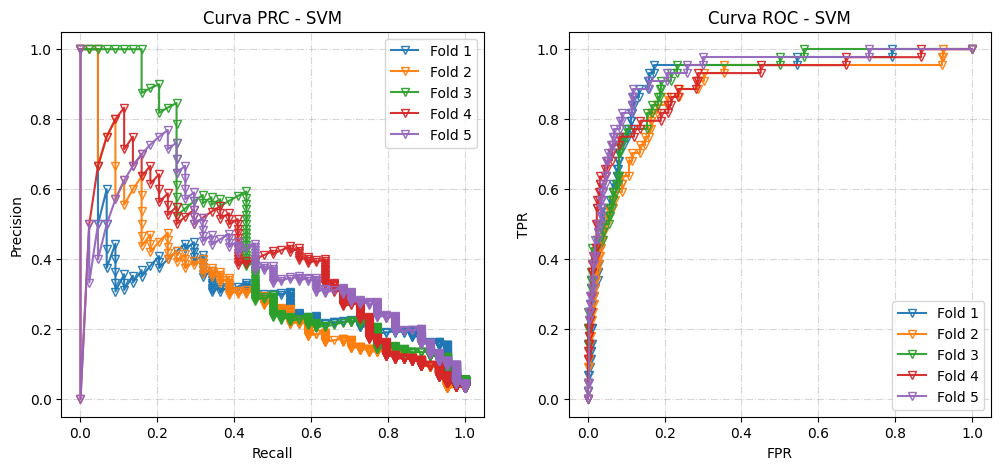

In [9]:
vt.plot_roc_prc_curves(roc_dict = bl_svc_roc, prc_dict = bl_svc_prc, title = "SVM")

# Regresión Logística

In [10]:
scaler = MinMaxScaler()
#Definimos el modelo (RL):
lr = LogisticRegression(random_state=seed,
                            fit_intercept= True, 
                            solver = "newton-cholesky",
                            tol=1e-6, 
                            warm_start= False,
                            class_weight="balanced", max_iter=1000)

lr_pipe = sk_Pipeline(steps = [("scaler", scaler), ("lr", lr)])

bl_lr_metrics_eval, bl_lr_roc, bl_lr_prc = mt.train_eval_model(lr_pipe, fold_maker, features, target)

In [11]:
bl_lr_metric_mean = mt.metrics_stats(bl_lr_metrics_eval)
print("Métricas promedio para el modelo de regresión logística:")
bl_lr_metric_mean.head()

Métricas promedio para el modelo de regresión logística:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.8594,0.0027
1,recall,0.8182,0.0557
2,precision,0.1636,0.0071
3,f1,0.2727,0.0128


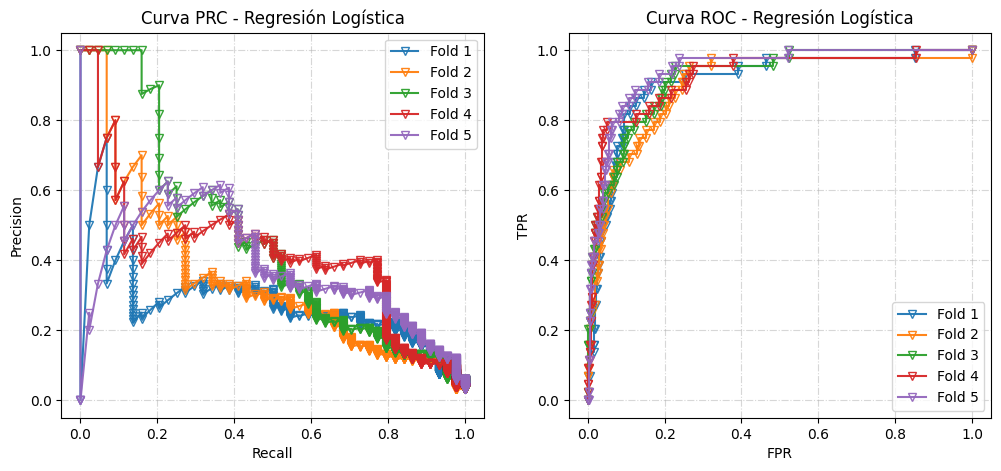

In [12]:
vt.plot_roc_prc_curves(roc_dict = bl_lr_roc, prc_dict = bl_lr_prc, title = "Regresión Logística")

# RANDOM FOREST

In [13]:
#Definimos el modelo (RF):
rf = RandomForestClassifier(random_state=seed, 
                            min_samples_split=10, n_estimators=500, n_jobs=-1, class_weight="balanced")

rf_pipe = sk_Pipeline(steps = [("rf", rf)])

bl_rf_metrics_eval, bl_rf_roc, bl_rf_prc = mt.train_eval_model(rf_pipe, fold_maker, features, target)

In [14]:
bl_rf_metric_mean = mt.metrics_stats(bl_rf_metrics_eval)
print("Métricas promedio para el Random Forest:")
bl_rf_metric_mean.head()

Métricas promedio para el Random Forest:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.9698,0.0021
1,recall,0.2045,0.0380
2,precision,0.6012,0.0877
3,f1,0.3031,0.0485


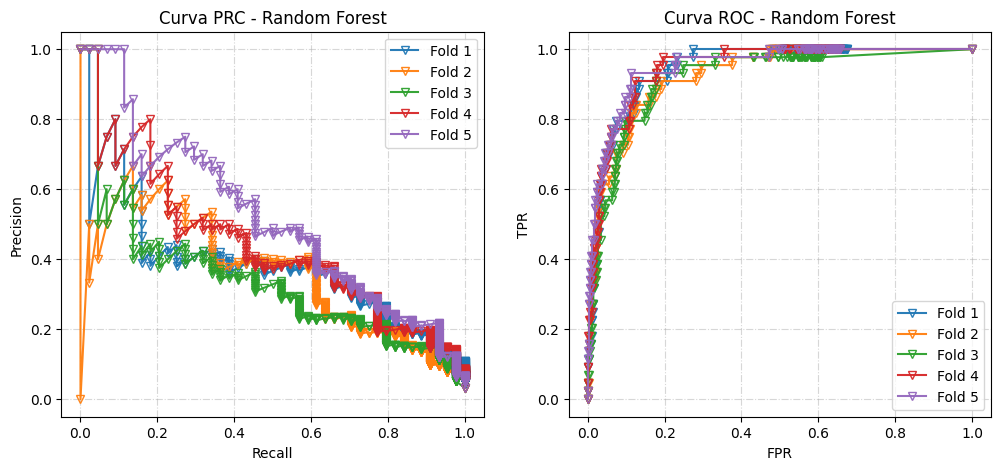

In [15]:
vt.plot_roc_prc_curves(roc_dict = bl_rf_roc, prc_dict = bl_rf_prc, title = "Random Forest")

# XGBOOST

In [16]:
#Definimos el modelo (XGBoost):
scale_pos_weight = 30 #n_neg/n_pos
xgb = XGBClassifier(random_state=seed, 
                         n_estimators=500, n_jobs=-1, scale_pos_weight= scale_pos_weight)

xgb_pipe = sk_Pipeline(steps = [("xgb", xgb)])

bl_xgb_metrics_eval, bl_xgb_roc, bl_xgb_prc = mt.train_eval_model(xgb_pipe, fold_maker, features, target)

In [17]:
bl_xgb_metric_mean = mt.metrics_stats(bl_xgb_metrics_eval)
print("Métricas promedio para el XGBoost:")
bl_xgb_metric_mean.head()

Métricas promedio para el XGBoost:


,Métrica,Promedio,Desv. Std.
0,accuracy,0.9691,0.0025
1,recall,0.3727,0.0422
2,precision,0.5404,0.0601
3,f1,0.4366,0.0211


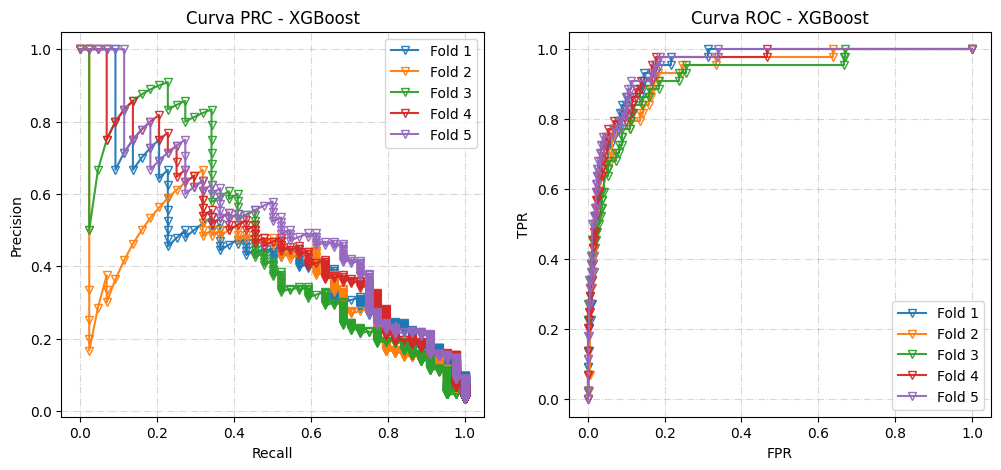

In [18]:
vt.plot_roc_prc_curves(roc_dict = bl_xgb_roc, prc_dict = bl_xgb_prc, title = "XGBoost")

In [43]:
def avg_auc(curve_dict: dict, prc: bool = True, std: bool = True):

    x_coordinates, y_coordinates, *tresholds = curve_dict.values()
    aucs = np.zeros(len(x_coordinates))

    for i in range(len(x_coordinates)):
        aucs[i] = auc(x_coordinates[i], y_coordinates[i]) if not prc else auc(y_coordinates[i], x_coordinates[i])

    return np.mean(aucs), np.std(aucs)

In [46]:
svm_prc_auc = avg_auc(bl_svc_prc, prc = True)
lr_prc_auc = avg_auc(bl_lr_prc, prc = True)
rf_prc_auc = avg_auc(bl_rf_prc, prc = True)
xgb_prc_auc = avg_auc(bl_xgb_prc, prc = True)



In [49]:
print(f"PRC-AUC PROMEDIO ({n_splits} folds)")
print(f"SVM: {svm_prc_auc[0]}")
print(f"REG. LOG.: {lr_prc_auc[0]}")
print(f"RANDOM FOREST: {rf_prc_auc[0]}")
print(f"XGBOOST: {xgb_prc_auc[0]}")

PRC-AUC PROMEDIO (5 folds)
SVM: 0.37143656202153746
REG. LOG.: 0.37196021210595376
RANDOM FOREST: 0.40281905043279875
XGBOOST: 0.46838275861452205


## La regresión logística tiene el mayor recall en promedio, pero el xgboost tiene las mejores curvas PR, lo cual indica que, ajustando el treshold, se puede mejorar mucho el recall sin comprometer demasiado la precisión